# 09 — Collatz Embeddings (v1)

Treat dropping-set / Eisenstein / 3-adic / alpha / force / slope as a lens basis
on the integers. Integer vectors as concept encodings. Analogy arithmetic in
lens space. Iteration as rotation that anchoring lenses survive.

- **Spec:** `docs/superpowers/specs/2026-04-30-collatz-embeddings-design.md`
- **Plan:** `docs/superpowers/plans/2026-04-30-collatz-embeddings.md`
- **Code:** `collatz/embeddings/`


In [1]:
import sys
sys.path.insert(0, '..')
import random
import numpy as np
import matplotlib.pyplot as plt

from collatz.embeddings import Concept, Phi, LENS_REGISTRY, T, T_syracuse
from collatz.embeddings.lenses import sector, mod3, drop_class, alpha_prefix, force, slope_log
from collatz.embeddings.distance import cosine, l2, weighted, analogy, ablate_lens
from collatz.embeddings.iteration import _syr_step


## 1. Lens sanity & fixtures


In [2]:
fixtures = [
    (3,  {"sector": 2, "mod3": 0, "drop_class": 6,  "alpha_prefix": (1, 4, 0), "force": 4, "slope_log": 2*np.log2(3) - 4}),
    (5,  {"sector": 1, "mod3": 2, "drop_class": 3,  "alpha_prefix": (4, 0, 0), "force": 2}),
    (7,  {"sector": 5, "mod3": 1, "drop_class": 11, "alpha_prefix": (1, 1, 2), "force": 7}),
    (11, {"sector": 4, "mod3": 2, "drop_class": 8,  "alpha_prefix": (1, 2, 3), "force": 5}),
]
fns = {"sector": sector, "mod3": mod3, "drop_class": drop_class,
       "alpha_prefix": alpha_prefix, "force": force, "slope_log": slope_log}

ok_count = fail_count = 0
for n, expected in fixtures:
    for k, v in expected.items():
        got = fns[k](n)
        ok = np.isclose(got, v) if isinstance(v, float) else got == v
        marker = "OK " if ok else "FAIL"
        print(f"n={n:>3}  {k:<13} got={got!r:<15}  expected={v!r:<15} {marker}")
        if ok: ok_count += 1
        else:  fail_count += 1
print(f"\n{ok_count} ok, {fail_count} fail")


n=  3  sector        got=2                expected=2               OK 
n=  3  mod3          got=0                expected=0               OK 
n=  3  drop_class    got=6                expected=6               OK 
n=  3  alpha_prefix  got=(1, 4, 0)        expected=(1, 4, 0)       OK 
n=  3  force         got=4                expected=4               OK 
n=  3  slope_log     got=-0.8300749985576878  expected=np.float64(-0.8300749985576878) OK 
n=  5  sector        got=1                expected=1               OK 
n=  5  mod3          got=2                expected=2               OK 
n=  5  drop_class    got=3                expected=3               OK 
n=  5  alpha_prefix  got=(4, 0, 0)        expected=(4, 0, 0)       OK 
n=  5  force         got=2                expected=2               OK 
n=  7  sector        got=5                expected=5               OK 
n=  7  mod3          got=1                expected=1               OK 
n=  7  drop_class    got=11               expected=11    

Even n and n=1 lift to sentinels — verify the fallback path:


In [3]:
for n in [1, 2, 6, 27, 100]:
    print(f"n={n:>4}: sector={sector(n)}, mod3={mod3(n)}, drop_class={drop_class(n)}, "
          f"alpha_prefix={alpha_prefix(n)}, force={force(n)}, slope_log={slope_log(n):+.3f}")


n=   1: sector=0, mod3=1, drop_class=0, alpha_prefix=(0, 0, 0), force=0, slope_log=+0.000
n=   2: sector=0, mod3=2, drop_class=1, alpha_prefix=(0, 0, 0), force=1, slope_log=-1.000
n=   6: sector=2, mod3=0, drop_class=1, alpha_prefix=(1, 4, 0), force=1, slope_log=-1.000
n=  27: sector=5, mod3=0, drop_class=96, alpha_prefix=(1, 2, 1), force=59, slope_log=-0.356
n= 100: sector=7, mod3=1, drop_class=1, alpha_prefix=(2, 1, 3), force=1, slope_log=-1.000


## 2. Pure-concept geometry

Construct fully-pure concepts (all components share a dropping set) and mixed concepts.
PCA the embeddings; pure concepts should cluster by class.


In [4]:
from collatz.utils import members_of_class
from collatz.dropping import dropping_set

set3 = members_of_class(dropping_set, 3, 200)
set6 = members_of_class(dropping_set, 6, 200)
set8 = members_of_class(dropping_set, 8, 200)

print(f"set3: first 9 = {set3[:9]}")
print(f"set6: first 9 = {set6[:9]}")
print(f"set8: first 6 = {set8[:6]}")

random.seed(0)
concepts = [
    Concept("pure_set3_a", tuple(set3[0:3])),
    Concept("pure_set3_b", tuple(set3[3:6])),
    Concept("pure_set3_c", tuple(set3[6:9])),
    Concept("pure_set6_a", tuple(set6[0:3])),
    Concept("pure_set6_b", tuple(set6[3:6])),
    Concept("pure_set8_a", tuple(set8[0:3])),
    Concept("mix_36",      (set3[0], set6[0], set3[1])),
    Concept("mix_68",      (set6[0], set8[0], set6[1])),
]
X = np.stack([Phi(c) for c in concepts])
print(f"\nembedding shape: {X.shape}")


set3: first 9 = [5, 9, 13, 17, 21, 25, 29, 33, 37]
set6: first 9 = [3, 19, 35, 51, 67, 83, 99, 115, 131]
set8: first 6 = [11, 23, 43, 55, 75, 87]

embedding shape: (8, 219)


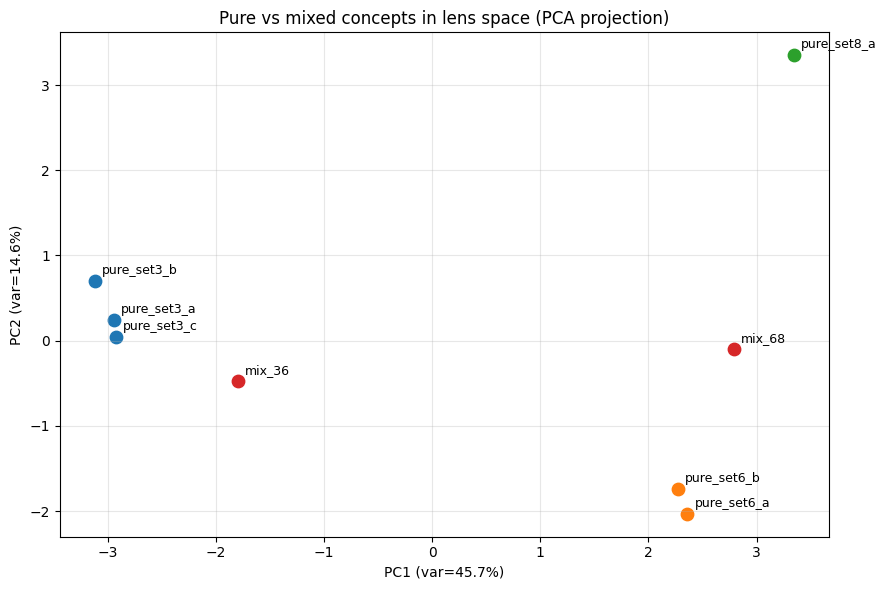

In [5]:
Xc = X - X.mean(0, keepdims=True)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
proj = Xc @ Vt.T[:, :2]

color_map = {"set3": "tab:blue", "set6": "tab:orange", "set8": "tab:green", "mix": "tab:red"}
def color_of(name):
    for k, v in color_map.items():
        if k in name: return v
    return "k"

fig, ax = plt.subplots(figsize=(9, 6))
for c, p in zip(concepts, proj):
    ax.scatter(*p, s=80, color=color_of(c.name))
    ax.annotate(c.name, p, fontsize=9, xytext=(5, 5), textcoords="offset points")
ax.set_xlabel(f"PC1 (var={S[0]**2/sum(S**2):.1%})")
ax.set_ylabel(f"PC2 (var={S[1]**2/sum(S**2):.1%})")
ax.set_title("Pure vs mixed concepts in lens space (PCA projection)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Expectation:** pure-set_k concepts should cluster together; mixed concepts sit between them.
The size of the gap between clusters tells us how much semantic load `drop_class` carries
relative to the other lenses.


## 3. Hand-built analogy quads

Build structurally-designed quads where we *know* an analogy should exist:
each quad has the form (a, T_syr(a), c, T_syr(c)) — same Syracuse-step transformation
applied to different starting concepts. If the embedding captures dynamical structure,
`analogy(a, T_syr(a), c)` should rank `T_syr(c)` highly.


In [6]:
def shift_concept(c: Concept) -> Concept:
    return Concept(c.name + "_shifted", tuple(_syr_step(x) for x in c.vec))

quads = []
for ns in [(3, 5, 7), (11, 13, 17), (19, 23, 27), (29, 31, 33), (35, 37, 41)]:
    a = Concept(f"a_{ns[0]}", ns)
    b = shift_concept(a)
    c_starts = tuple(x + 4 for x in ns)
    c = Concept(f"c_{c_starts[0]}", c_starts)
    d = shift_concept(c)
    quads.append((a, b, c, d))

print(f"Built {len(quads)} analogy quads.")
for a, b, c, d in quads:
    print(f"  {a.name}({a.vec}) -> {b.name}({b.vec}) :: {c.name}({c.vec}) -> {d.name}({d.vec})")


Built 5 analogy quads.
  a_3((3, 5, 7)) -> a_3_shifted((5, 1, 11)) :: c_7((7, 9, 11)) -> c_7_shifted((11, 7, 17))
  a_11((11, 13, 17)) -> a_11_shifted((17, 5, 13)) :: c_15((15, 17, 21)) -> c_15_shifted((23, 13, 1))
  a_19((19, 23, 27)) -> a_19_shifted((29, 35, 41)) :: c_23((23, 27, 31)) -> c_23_shifted((35, 41, 47))
  a_29((29, 31, 33)) -> a_29_shifted((11, 47, 25)) :: c_33((33, 35, 37)) -> c_33_shifted((25, 53, 7))
  a_35((35, 37, 41)) -> a_35_shifted((53, 7, 31)) :: c_39((39, 41, 45)) -> c_39_shifted((59, 31, 17))


In [7]:
random.seed(1)
distractors = [
    Concept(f"dist_{i}", tuple(random.randint(2, 1000) for _ in range(3)))
    for i in range(50)
]

ranks = []
for a, b, c, expected_d in quads:
    pool = distractors + [expected_d]
    ranked = analogy(a, b, c, pool)
    rank = next(i for i, (cand, _) in enumerate(ranked) if cand is expected_d)
    score = next(s for cand, s in ranked if cand is expected_d)
    ranks.append(rank)
    print(f"{a.name} -> {b.name} :: {c.name} -> ?  expected_rank={rank}/{len(pool)}  score={score:+.3f}")

print(f"\nMean rank of expected d: {np.mean(ranks):.1f} (chance baseline: {len(distractors)/2:.1f})")
print(f"Top-5 hit rate: {sum(1 for r in ranks if r < 5)}/{len(ranks)}")


a_3 -> a_3_shifted :: c_7 -> ?  expected_rank=14/51  score=+0.660
a_11 -> a_11_shifted :: c_15 -> ?  expected_rank=7/51  score=+0.757
a_19 -> a_19_shifted :: c_23 -> ?  expected_rank=0/51  score=+0.898
a_29 -> a_29_shifted :: c_33 -> ?  expected_rank=26/51  score=+0.345
a_35 -> a_35_shifted :: c_39 -> ?  expected_rank=9/51  score=-0.064

Mean rank of expected d: 11.2 (chance baseline: 25.0)
Top-5 hit rate: 1/5


## 4. Iteration drift & anchoring

For each quad, iterate components k = 0..K Syracuse steps. Plot the cosine between
the *initial* analogy direction Phi(b) - Phi(a) and the *iterated* analogy direction
Phi(T^k b) - Phi(T^k a). If anchoring lenses (sector, mod3, slope_log) dominate,
the analogy survives many iterations. If decaying lenses (force, alpha_prefix) dominate,
it dissolves quickly.


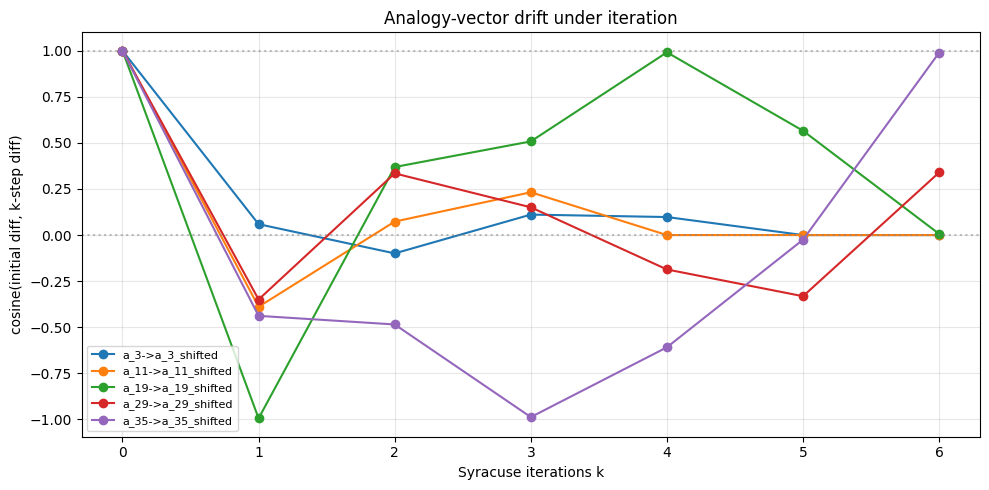

In [8]:
def iterate_concept(c: Concept, k: int) -> Concept:
    for _ in range(k):
        c = T_syracuse(c)
    return c

K = 6
fig, ax = plt.subplots(figsize=(10, 5))
for a, b, c, _ in quads:
    base_diff = Phi(b) - Phi(a)
    drifts = []
    for k in range(K + 1):
        ak = iterate_concept(a, k)
        bk = iterate_concept(b, k)
        diff_k = Phi(bk) - Phi(ak)
        drifts.append(cosine(diff_k, base_diff))
    ax.plot(range(K + 1), drifts, marker="o", label=f"{a.name}->{b.name}")
ax.set_xlabel("Syracuse iterations k")
ax.set_ylabel("cosine(initial diff, k-step diff)")
ax.set_title("Analogy-vector drift under iteration")
ax.legend(fontsize=8, loc="lower left")
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5)
ax.axhline(0.0, color="gray", linestyle=":", alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Lens ablation.** Zero one lens at a time and re-run the analogy ranking. Worse rank means that lens carries more analogy signal.


In [9]:
print(f"{'lens':<13} {'mean rank':>10} {'top-5':>6}")
print("-" * 32)

ranks_full = []
for a, b, c, expected_d in quads:
    pool = distractors + [expected_d]
    ranked = analogy(a, b, c, pool)
    rank = next(i for i, (cand, _) in enumerate(ranked) if cand is expected_d)
    ranks_full.append(rank)
print(f"{'(all)':<13} {np.mean(ranks_full):>10.2f} {sum(1 for r in ranks_full if r < 5):>6}")

for lens_name in ["sector", "mod3", "drop_class", "alpha_prefix", "force", "slope_log"]:
    w = ablate_lens(lens_name, m=3)
    ranks = []
    for a, b, c, expected_d in quads:
        pool = distractors + [expected_d]
        ranked = analogy(a, b, c, pool, weight=w)
        rank = next(i for i, (cand, _) in enumerate(ranked) if cand is expected_d)
        ranks.append(rank)
    print(f"-{lens_name:<12} {np.mean(ranks):>10.2f} {sum(1 for r in ranks if r < 5):>6}")


lens           mean rank  top-5
--------------------------------
(all)              11.20      1
-sector            11.20      1


-mod3              10.00      1
-drop_class        11.00      1
-alpha_prefix       9.60      1
-force             23.40      2
-slope_log         10.40      1


**Reading the ablation table:** rows where the mean rank gets *much worse* are the lenses
carrying the analogy. Rows where rank stays similar to baseline indicate redundant or noise lenses.

## 5. Open questions for v2

A few directions that emerged from this first pass:

- **Component coupling.** Components currently evolve independently under T. A natural v2:
  apply one Collatz step to whichever component has the highest `force`, treating the
  concept as a single dynamical entity rather than a parallel bundle.
- **Learned lens weights.** Gradient-fit axis weights against a labeled analogy set
  rather than treating all lenses equal. The ablation table is a primitive form of this.
- **Longer alpha-prefixes** or full alpha-trajectories as a richer dynamical fingerprint
  (effectively folding Approach B from the spec into Approach A as one richer lens).
- **Cross-component lens correlations** — embed not just `Phi(n_i)` per i but pairwise
  differences `sector(n_i) - sector(n_j)`, etc. This would capture *internal structure*
  of a concept beyond the bag-of-projections view.
- **Analogy rank vs `force`.** Hypothesis: high-force quads (well-determined claims)
  should preserve analogy under iteration longer than low-force quads. Test by binning
  drift curves by mean concept force.
